# 03 - Análisis en frecuencia, Cepstrum y Estimación Espectral

## ACUS340 - Procesamiento de Señales

En esta clase estudiaremos herramientas fundamentales para analizar señales acústicas reales en el dominio de la frecuencia.

Trabajaremos con grabaciones de cinco clases presentes en nuestro dataset:

- *Batrachyla leptopus*
- *Batrachyla taeniata*
- *Calyptocephalella gayi*
- *Pleurodema thaul*
- *Porzana spiloptera*

## Contenidos de la clase

1. Señales deterministas y señales aleatorias.
2. Transformada Discreta de Fourier, DFT.
3. Densidad Espectral de Potencia, PSD.
4. Estimación espectral mediante Welch.
5. Introducción al análisis Cepstrum.
6. Comparación entre señales acústicas reales.

## Objetivo general

Comprender cómo el análisis en frecuencia permite describir, comparar e interpretar señales acústicas reales.

## Objetivos específicos

Al finalizar la clase, las y los estudiantes serán capaces de:

- Diferenciar señales deterministas y aleatorias desde una perspectiva temporal y espectral.
- Implementar la DFT en Python.
- Estimar y visualizar la PSD de señales acústicas reales.
- Aplicar el método de Welch para obtener estimaciones espectrales más estables.
- Calcular e interpretar el Cepstrum como herramienta de análisis de periodicidades espectrales.
- Comparar patrones espectrales entre especies.

In [7]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

from scipy.fft import fft, fftfreq
from scipy.signal import welch
from IPython.display import Audio, display

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data" / "audios"

print("Project root:", PROJECT_ROOT)
print("Audio directory:", DATA_DIR)
print("Audio directory exists:", DATA_DIR.exists())

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260427_programa_acus340/acus340_signal_processing
Audio directory: /Users/vpoblete/Documents/20230208_vpoblete/20260427_programa_acus340/acus340_signal_processing/data/audios
Audio directory exists: True


In [4]:
species_dirs = sorted([p for p in DATA_DIR.iterdir() if p.is_dir()])

print("Species folders found:")
for i, folder in enumerate(species_dirs, start=1):
    print(f"{i}. {folder.name}")

Species folders found:
1. Batrachyla_leptopus
2. Batrachyla_taeniata
3. Calyptocephalella_gayi
4. Pleurodema_thaul
5. Porzana_spiloptera


# 1. Señales deterministas y señales aleatorias

En procesamiento de señales es importante distinguir entre señales **deterministas** y señales **aleatorias**.

Una señal determinista es aquella que puede describirse mediante una expresión matemática conocida. Por ejemplo, una señal sinusoidal pura:

$
x(t) = A \sin(2 \pi f_0 t)
$

donde:

- $A$ es la amplitud,
- $f_0$ es la frecuencia de la señal,
- $t$ es el tiempo.

En cambio, una señal aleatoria no puede predecirse exactamente en cada instante. Su comportamiento se describe usando herramientas estadísticas o espectrales.

En esta sección compararemos:

1. Una señal sinusoidal pura.
2. Una señal compuesta por dos frecuencias.
3. Una señal aleatoria tipo ruido blanco.
4. Una señal mixta: sinusoidal + ruido.

El objetivo es observar cómo cambia la representación temporal y frecuencial en cada caso.

In [9]:
# Parámetros generales
fs = 10000          # Frecuencia de muestreo en Hz
duration = 2.0     # Duración en segundos

t = np.arange(0, duration, 1/fs)

# Señal determinista 1: una sinusoidal pura
f0 = 500  # Hz
x_sine = np.sin(2 * np.pi * f0 * t)

# Señal determinista 2: suma de dos sinusoidales
f1 = 500
f2 = 120
x_two_sines = np.sin(2 * np.pi * f1 * t) + 0.5 * np.sin(2 * np.pi * f2 * t)

# Señal aleatoria: ruido blanco
np.random.seed(42)
x_noise = np.random.normal(0, 1, len(t))

# Señal mixta: sinusoidal + ruido
x_mixed = x_sine + 0.5 * x_noise

print("Número de muestras:", len(t))
print("Frecuencia de muestreo:", fs, "Hz")
print("Duración:", duration, "s")

Número de muestras: 20000
Frecuencia de muestreo: 10000 Hz
Duración: 2.0 s


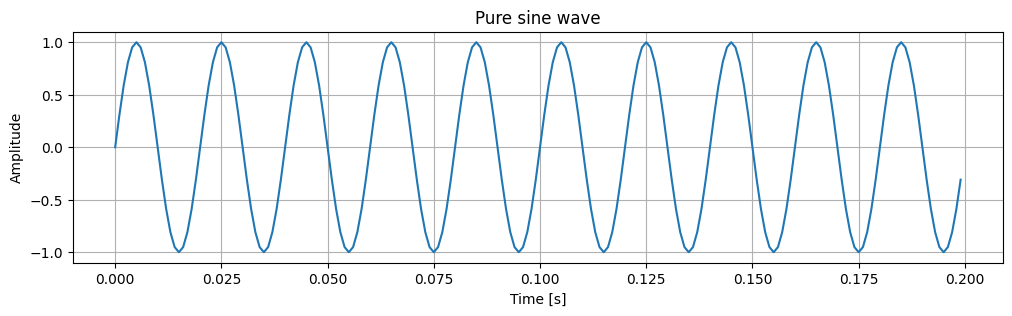

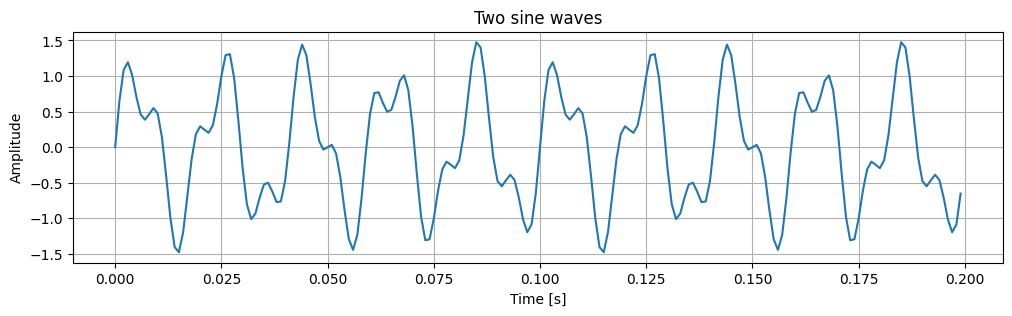

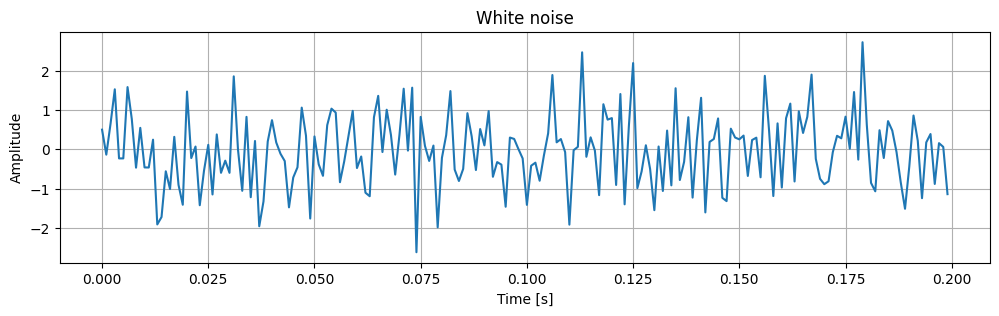

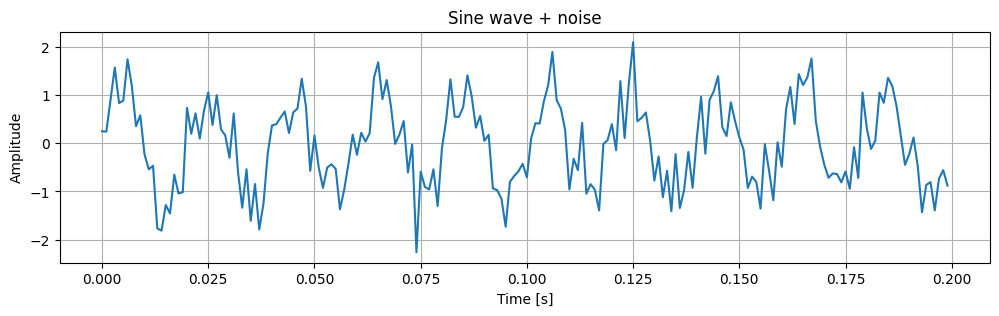

In [6]:
signals = {
    "Pure sine wave": x_sine,
    "Two sine waves": x_two_sines,
    "White noise": x_noise,
    "Sine wave + noise": x_mixed
}

time_limit = 0.2  # segundos para visualizar mejor las oscilaciones
n_limit = int(time_limit * fs)

for name, x in signals.items():
    plt.figure(figsize=(12, 3))
    plt.plot(t[:n_limit], x[:n_limit])
    plt.title(name)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

In [11]:
# Escuchar señales sintéticas

print("Pure sine wave - 500 Hz")
display(Audio(x_sine, rate=fs))

print("Two sine waves - 500 Hz + 120 Hz")
display(Audio(x_two_sines, rate=fs))

print("White noise")
display(Audio(x_noise, rate=fs))

print("Sine wave + noise")
display(Audio(x_mixed, rate=fs))

Pure sine wave - 500 Hz


Two sine waves - 500 Hz + 120 Hz


White noise


Sine wave + noise


## Discusión breve

Después de escuchar las señales, discutamos:

1. ¿Cuál señal se percibe como más tonal?
2. ¿Cuál señal se percibe como más ruidosa?
3. ¿Qué diferencia auditiva aparece al sumar dos frecuencias?
4. ¿Qué ocurre perceptualmente cuando agregamos ruido a una señal sinusoidal?
5. ¿Esperamos que estas diferencias se vean en la DFT y en la PSD?

Esta discusión conecta la percepción auditiva con la representación matemática de la señal.